In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

dates = pd.date_range(start='2023-01-01' , periods=365,freq='D')
values = [100+ i + 10*np.sin(2*np.pi*i/30) + np.random.randn()*5 for i in range(365)]

In [6]:
print(np.sin(2*np.pi*1/30))
print(np.sin(2*np.pi*2/30))
print(np.sin(2*np.pi*3/30))

0.20791169081775931
0.40673664307580015
0.5877852522924731


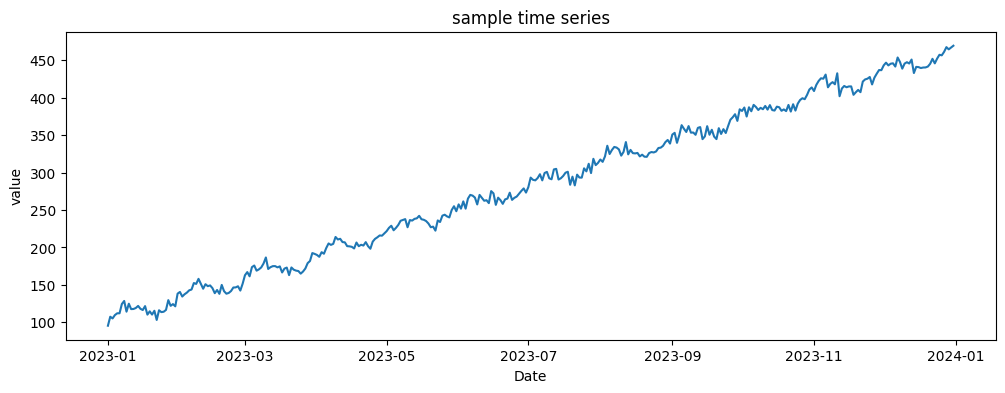

In [7]:
ts = pd.Series(values,index=dates)
plt.figure(figsize=(12,4))
plt.plot(ts)
plt.title('sample time series')
plt.xlabel('Date')
plt.ylabel('value')
plt.show()

In [8]:
np.arange(2)

array([0, 1])

In [10]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.6 MB 12.1 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.6 MB 12.5 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 12.0 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.6 MB 11.1 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.6 MB 9.8 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 7.2 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.6 MB 7.0 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.6 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.7 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]

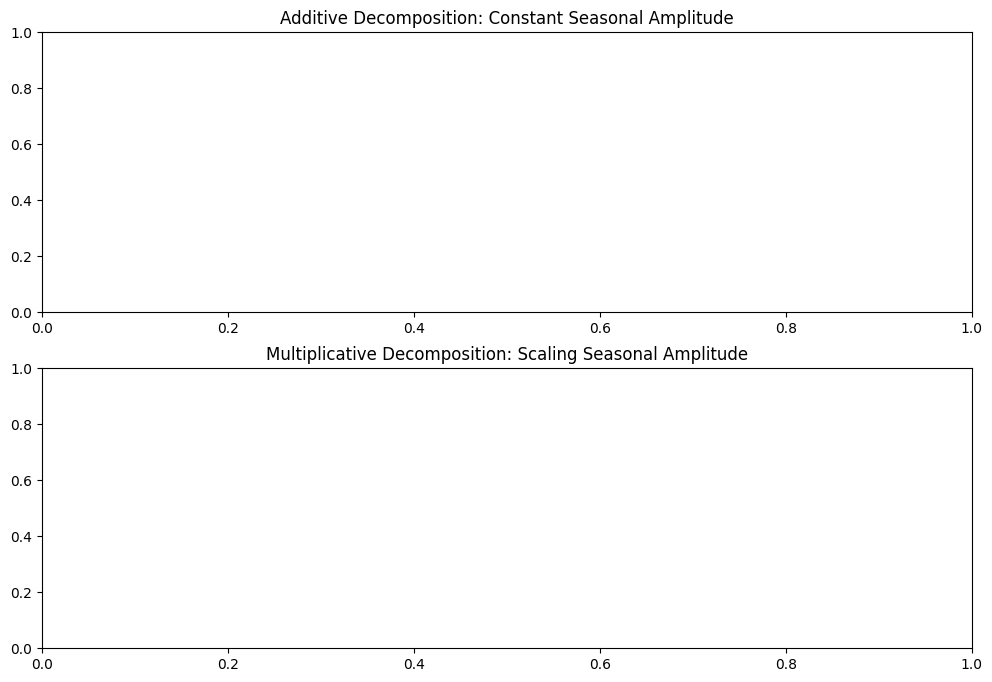

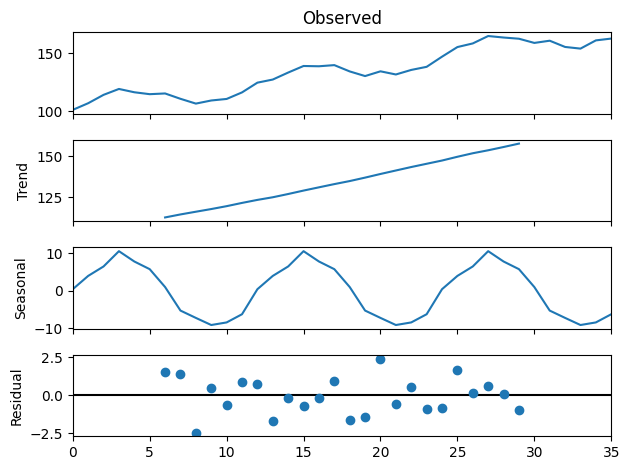

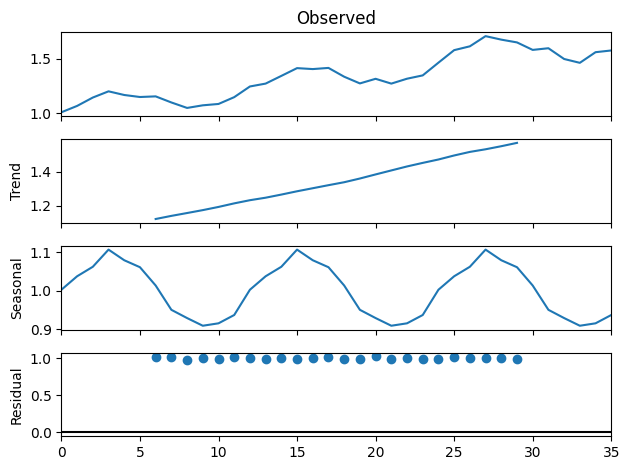

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Set seed for reproducibility
np.random.seed(42)

# Create 3 years of monthly data
months = 36
time = np.arange(months)

# Trend: Linear increase
trend = 100 + 2 * time

# Seasonal pattern (yearly cycle)
seasonal = 10 * np.sin(2 * np.pi * time / 12)

# Noise
noise = np.random.randn(months) * 2

# Additive model: Seasonal amplitude is constant
additive_series = trend + seasonal + noise

# Multiplicative model: Seasonal amplitude scales with trend
# (seasonal effect is 10% of current level)
multiplicative_series = (trend / 100) * (1 + seasonal / 100) * (1 + noise / 100)

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Additive
decomp_add = seasonal_decompose(additive_series, model='additive', period=12)
decomp_add.plot()
axes[0].set_title('Additive Decomposition: Constant Seasonal Amplitude')
plt.tight_layout()

# Multiplicative  
decomp_mult = seasonal_decompose(multiplicative_series, model='multiplicative', period=12)
decomp_mult.plot()
axes[1].set_title('Multiplicative Decomposition: Scaling Seasonal Amplitude')
plt.tight_layout()

plt.show()

# Key observation: In multiplicative, seasonal component varies with trend level

In [2]:
from statsmodels.tsa.stattools import adfuller
import numpy as np

data = np.cumsum(np.random.randn(100))

result = adfuller(data)

print(f'adf statistic : {result[0]:.4f}')
print(f'P-value : {result[1]:.4f}')

if result[1] <0.05:
    print("stationary")
else:
    print("Non -stationary -differencing needed")

adf statistic : -2.2349
P-value : 0.1938
Non -stationary -differencing needed


C:\Users\damod\AppData\Local\Temp\ipykernel_792\2302457009.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot(monthly_data, labels=['Jan','Feb','Mar','Apr','May','Jun',


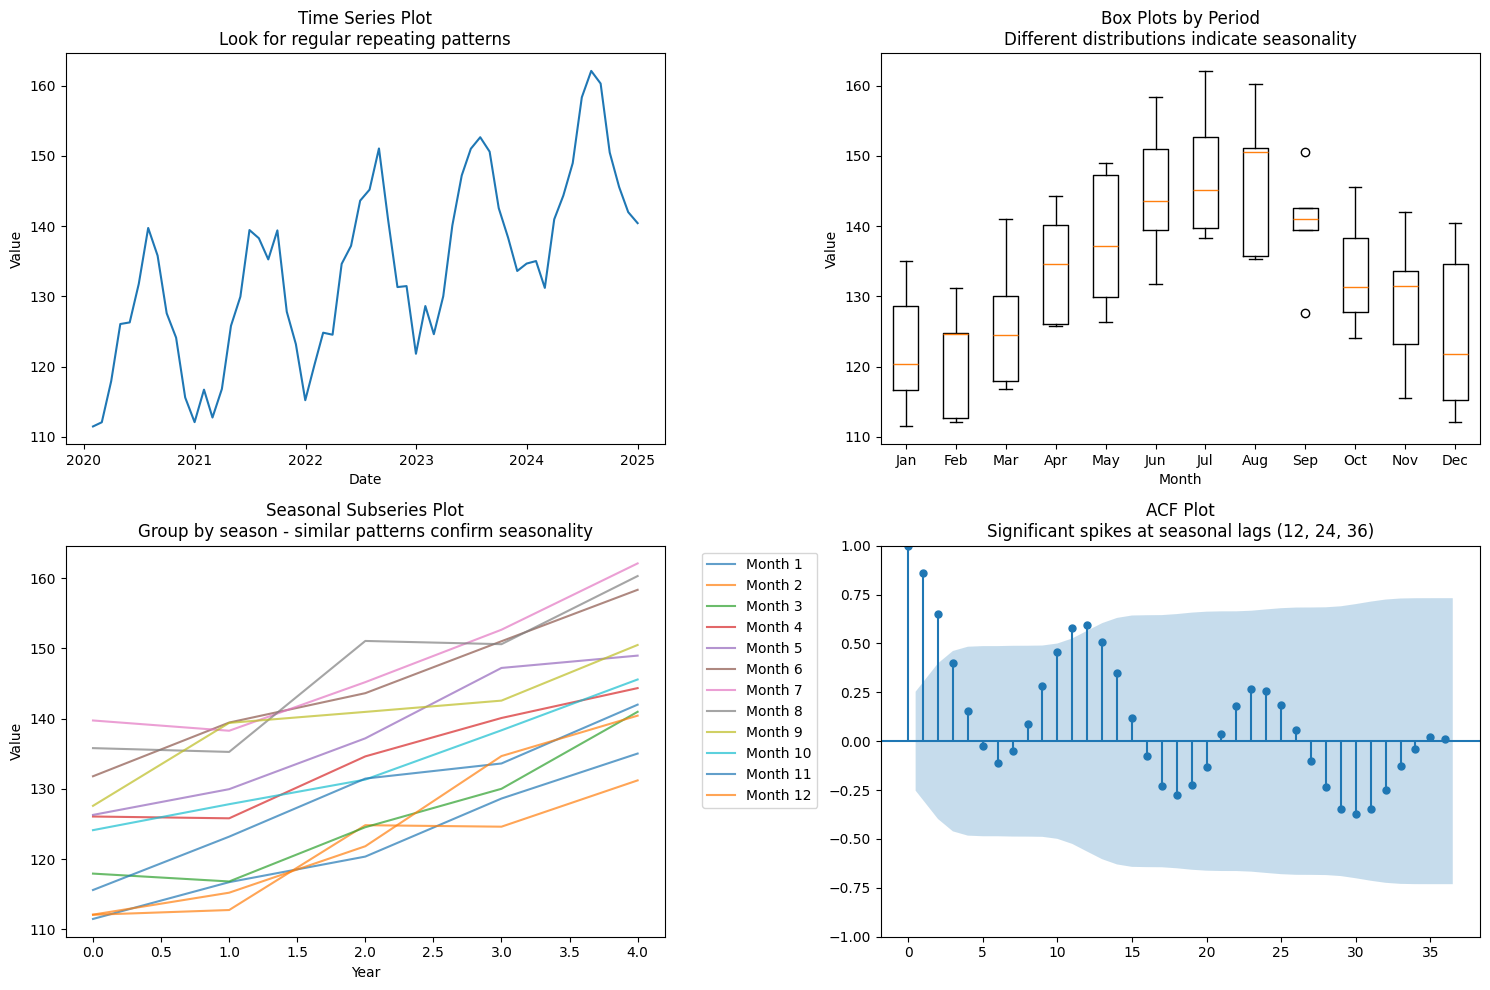

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Generate seasonal time series data (5 years monthly)
np.random.seed(42)
years = 5
months = years * 12
dates = pd.date_range(start='2020-01-01', periods=months, freq='ME')

# Trend: slight upward
trend = 100 + 0.5 * np.arange(months)

# Seasonal pattern (monthly)
seasonal_pattern = np.array([10, 12, 15, 20, 25, 30, 32, 30, 25, 18, 12, 8])
seasonal = np.tile(seasonal_pattern, years)

# Noise
noise = np.random.randn(months) * 3

# Combine
data = trend + seasonal + noise
ts = pd.Series(data, index=dates)

# 1. Time Series Plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0,0].plot(ts)
axes[0,0].set_title('Time Series Plot\nLook for regular repeating patterns')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Value')

# 2. Seasonal Subseries Plot
# Group by month and plot each month's values
monthly_data = [ts[ts.index.month == m].values for m in range(1, 13)]
axes[0,1].boxplot(monthly_data, labels=['Jan','Feb','Mar','Apr','May','Jun',
                                         'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0,1].set_title('Box Plots by Period\nDifferent distributions indicate seasonality')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Value')

# 3. Seasonal Subseries Plot (line version)
for m in range(1, 13):
    month_data = ts[ts.index.month == m]
    axes[1,0].plot(range(len(month_data)), month_data.values, 
                   label=f'Month {m}', alpha=0.7)
axes[1,0].set_title('Seasonal Subseries Plot\nGroup by season - similar patterns confirm seasonality')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Value')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. ACF Plot
plot_acf(ts, lags=36, ax=axes[1,1])
axes[1,1].set_title('ACF Plot\nSignificant spikes at seasonal lags (12, 24, 36)')

plt.tight_layout()
plt.show()

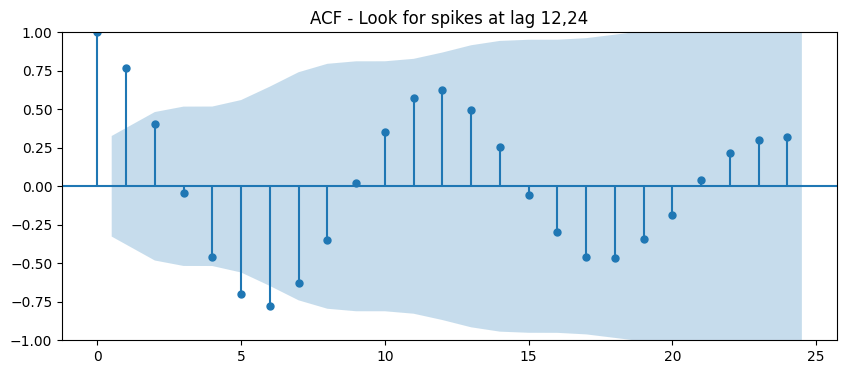

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

np.random.seed(42)
months = 36
seasonal_pattern = [10, 12, 15, 20, 25, 30, 32, 30, 25, 18, 12, 8] 
data = [seasonal_pattern[i%12] + np.random.randn()*2 for i in range(months)]

fig , ax = plt.subplots(figsize=(10,4))
plot_acf(data,lags=24,ax=ax)
plt.title('ACF - Look for spikes at lag 12,24')
plt.show()

In [9]:
import numpy as np
import pandas as pd

t = np.arange(10)
trend_data = 50 + 2*t + np.random.randn(10)*5

differenced = np.diff(trend_data)
print(f"Original mean: {trend_data.mean():.2f}")  # Changes over time
print(f"Differenced mean: {differenced.mean():.2f}")

Original mean: 59.51
Differenced mean: 2.77


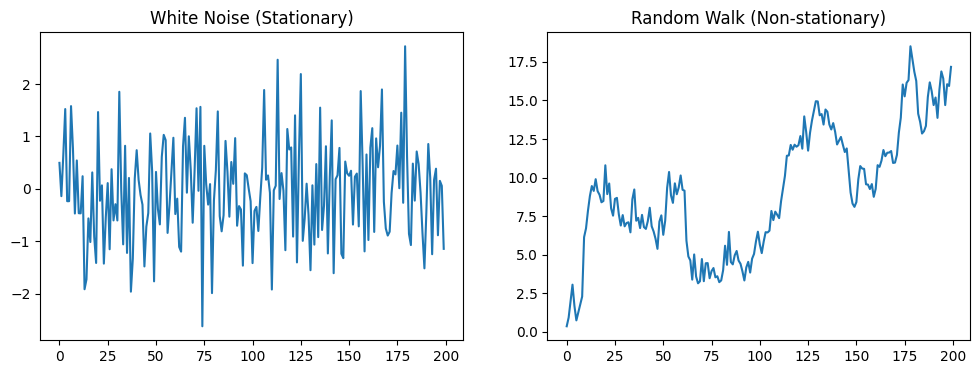

In [10]:

import numpy as np
import matplotlib.pyplot as plt

# Pipeline: Generate both -> Plot -> Compare ACF patterns

np.random.seed(42)
n = 200

# White Noise
white_noise = np.random.randn(n)

# Random Walk (cumulative sum of white noise)
random_walk = np.cumsum(np.random.randn(n))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(white_noise)
axes[0].set_title('White Noise (Stationary)')

axes[1].plot(random_walk)
axes[1].set_title('Random Walk (Non-stationary)')
plt.show()

# Key observation: Random walk "wanders" far from origin; white noise stays bounded



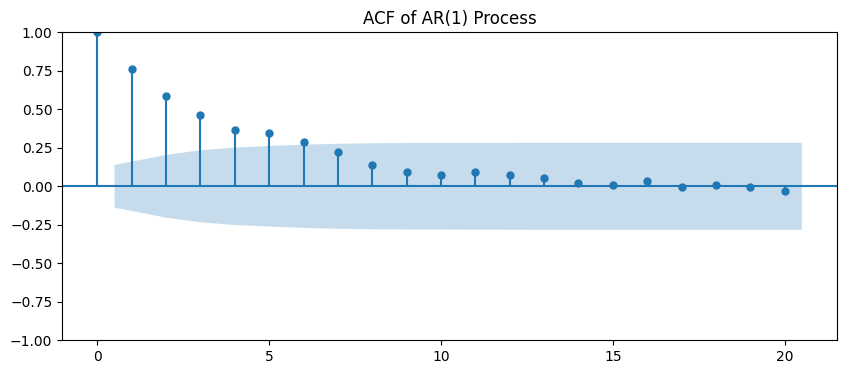

In [18]:
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n =  200
y  =np.zeros(n)
for t in range(1,n):
    y[t] = 0.8* y[t-1] + np.random.randn()
    
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(y, lags=20, ax=ax)
plt.title('ACF of AR(1) Process')
plt.show()

In [19]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# Pipeline: Create trending data -> Difference -> Verify stationarity

# Step 1: Non-stationary data (random walk)
np.random.seed(42)
random_walk = np.cumsum(np.random.randn(100))

# Step 2: Apply first difference
differenced = np.diff(random_walk)

# Step 3: Test stationarity
def adf_test(data, name):
    result = adfuller(data)
    print(f"{name}: ADF={result[0]:.2f}, p-value={result[1]:.4f}")

adf_test(random_walk, "Original")      # p > 0.05 (non-stationary)
adf_test(differenced, "Differenced")

Original: ADF=-1.36, p-value=0.6021
Differenced: ADF=-10.01, p-value=0.0000


In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt

dates = pd.date_range(start='2023-01-01',periods=365,freq='D')
dates

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25',
               '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29',
               '2023-12-30', '2023-12-31'],
              dtype='datetime64[us]', length=365, freq='D')

In [ ]:
values = [100 + 0.5*i + 10*np.sin(2*np.pi*i/30) + np.random.randn()*5 for i in range(365)]
values

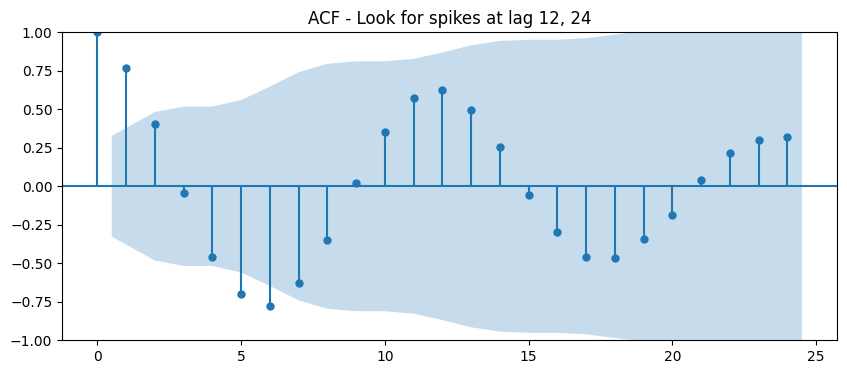

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Pipeline: Load data -> Plot ACF -> Look for seasonal spikes

# Step 1: Create monthly data with yearly seasonality
np.random.seed(42)
months = 36  # 3 years
seasonal_pattern = [10, 12, 15, 20, 25, 30, 32, 30, 25, 18, 12, 8]  # monthly pattern
data = [seasonal_pattern[i % 12] + np.random.randn()*2 for i in range(months)]

# Step 2: Plot ACF
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(data, lags=24, ax=ax)
plt.title('ACF - Look for spikes at lag 12, 24')
plt.show()

# Output: Spikes at lag 12 and 24 indicate annual seasonality



In [3]:

import numpy as np
import pandas as pd

# Pipeline: Create trending data -> Apply differencing -> Check stationarity

# Step 1: Create data with linear trend
t = np.arange(100)
trend_data = 50 + 2*t + np.random.randn(100)*5  # Linear trend + noise

# Step 2: Remove trend via differencing
differenced = np.diff(trend_data)  # Y_t - Y_{t-1}

# Step 3: Compare
print(f"Original mean: {trend_data.mean():.2f}")  # Changes over time
print(f"Differenced mean: {differenced.mean():.2f}")  # ~2 (the slope)

# Output: Differenced series has constant mean ≈ slope of original trend



Original mean: 148.78
Differenced mean: 2.07


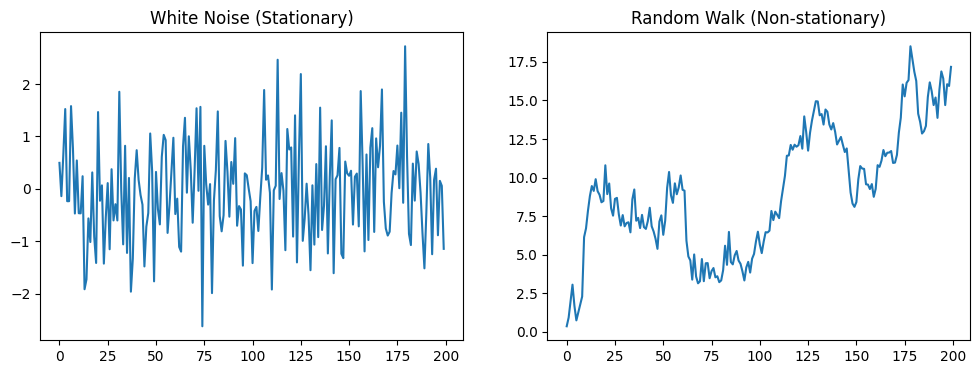

In [4]:

import numpy as np
import matplotlib.pyplot as plt

# Pipeline: Generate both -> Plot -> Compare ACF patterns

np.random.seed(42)
n = 200

# White Noise
white_noise = np.random.randn(n)

# Random Walk (cumulative sum of white noise)
random_walk = np.cumsum(np.random.randn(n))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(white_noise)
axes[0].set_title('White Noise (Stationary)')

axes[1].plot(random_walk)
axes[1].set_title('Random Walk (Non-stationary)')
plt.show()

# Key observation: Random walk "wanders" far from origin; white noise stays bounded


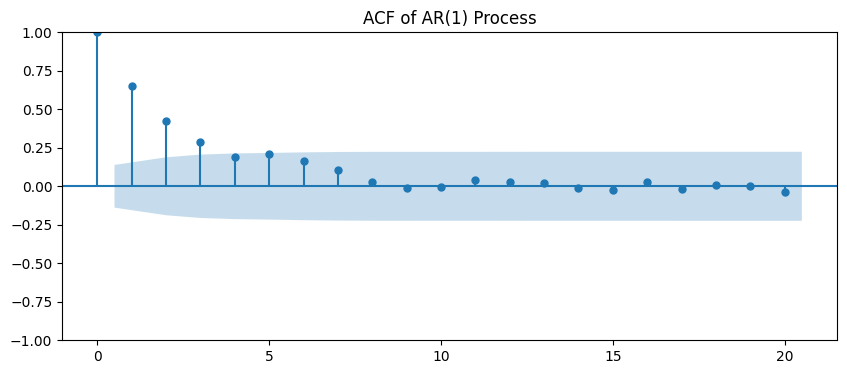

In [5]:

from statsmodels.graphics.tsaplots import plot_acf
import numpy as np
import matplotlib.pyplot as plt

# Pipeline: Create AR process -> Plot ACF -> Interpret decay pattern

np.random.seed(42)
n = 200

# Create AR(1) process: Y_t = 0.7*Y_{t-1} + noise
y = np.zeros(n)
for t in range(1, n):
    y[t] = 0.7 * y[t-1] + np.random.randn()

# Plot ACF
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(y, lags=20, ax=ax)
plt.title('ACF of AR(1) Process')
plt.show()

# Output: Exponentially decaying ACF (characteristic of AR process)
# Blue bands = 95% confidence interval; outside = significant




In [6]:

import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# Pipeline: Create trending data -> Difference -> Verify stationarity

# Step 1: Non-stationary data (random walk)
np.random.seed(42)
random_walk = np.cumsum(np.random.randn(100))

# Step 2: Apply first difference
differenced = np.diff(random_walk)

# Step 3: Test stationarity
def adf_test(data, name):
    result = adfuller(data)
    print(f"{name}: ADF={result[0]:.2f}, p-value={result[1]:.4f}")

adf_test(random_walk, "Original")      # p > 0.05 (non-stationary)
adf_test(differenced, "Differenced")   # p < 0.05 (stationary)

# Output: Differencing converts non-stationary random walk to stationary white noise




Original: ADF=-1.36, p-value=0.6021
Differenced: ADF=-10.01, p-value=0.0000


Coefficients: [-0.03924875  0.56416986 -0.33650173]


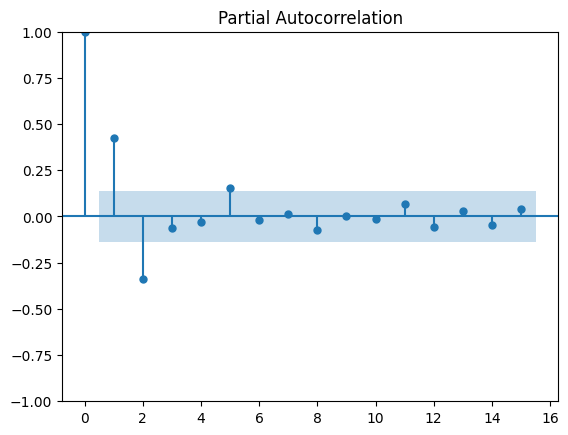

In [9]:

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_pacf
import numpy as np

# Pipeline: Create AR data -> Plot PACF to find p -> Fit model

np.random.seed(42)
n = 200

# Generate AR(2) process: Y_t = 0.6*Y_{t-1} - 0.3*Y_{t-2} + noise
y = np.zeros(n)
for t in range(2, n):
    y[t] = 0.6*y[t-1] - 0.3*y[t-2] + np.random.randn()

# Step 1: Use PACF to identify order (expect cutoff after lag 2)
plot_pacf(y, lags=15)

# Step 2: Fit AR(2) model
model = AutoReg(y, lags=2).fit()
print(f"Coefficients: {model.params}")





MA Coefficients: [-0.08324121  0.64111976  0.22554765  0.85475105]


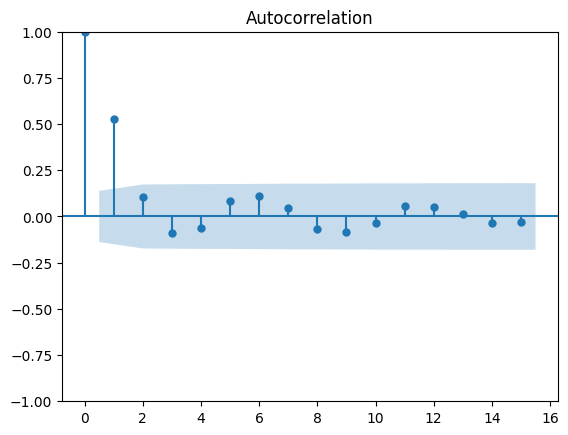

In [10]:

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np

# Pipeline: Create MA data -> Plot ACF to find q -> Fit model

np.random.seed(42)
n = 200

# Generate MA(2) process: Y_t = noise + 0.7*noise_{t-1} + 0.3*noise_{t-2}
errors = np.random.randn(n)
y = np.zeros(n)
for t in range(2, n):
    y[t] = errors[t] + 0.7*errors[t-1] + 0.3*errors[t-2]

# Step 1: ACF should cut off after lag 2
plot_acf(y, lags=15)

# Step 2: Fit MA(2) model using ARIMA(0,0,2)
model = ARIMA(y, order=(0, 0, 2)).fit()
print(f"MA Coefficients: {model.params}")





In [12]:

from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# Pipeline: Create ARMA data -> Try different orders -> Select by AIC

np.random.seed(42)
n = 200

# Generate ARMA(1,1): Y_t = 0.7*Y_{t-1} + noise + 0.5*noise_{t-1}
errors = np.random.randn(n)
y = np.zeros(n)
for t in range(1, n):
    y[t] = 0.7*y[t-1] + errors[t] + 0.5*errors[t-1]

# Fit different models, compare AIC
for p in [1, 2]:
    for q in [1, 2]:
        model = ARIMA(y, order=(p, 0, q)).fit()
        print(f"ARMA({p},{q}) - AIC: {model.aic:.2f}")
        print(f"Arima({p},{q}) - BIC: {model.bic:.2f}")

# Output: ARMA(1,1) should have lowest AIC (true model)




ARMA(1,1) - AIC: 546.05
Arima(1,1) - BIC: 559.25
ARMA(1,2) - AIC: 547.29
Arima(1,2) - BIC: 563.78
ARMA(2,1) - AIC: 546.66
Arima(2,1) - BIC: 563.15
ARMA(2,2) - AIC: 547.15
Arima(2,2) - BIC: 566.94


C:\Users\damod\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\damod\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Next 10 forecasts: [39.98405319 40.35275446 40.72145207 41.09014602 41.4588363 ]...


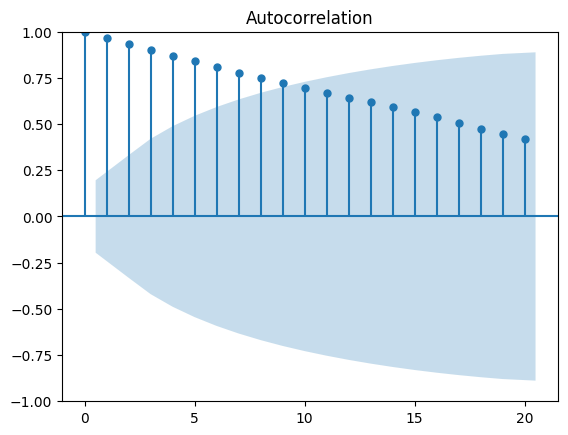

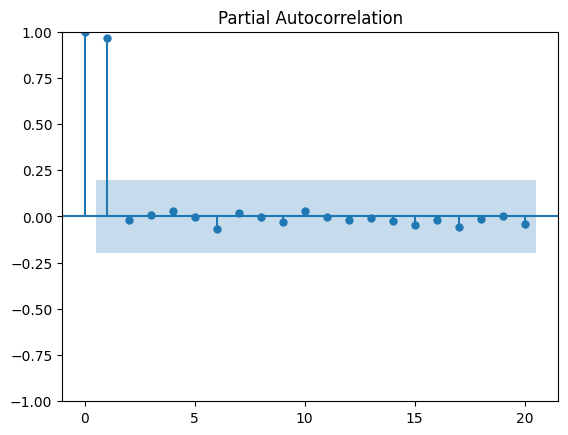

In [16]:

from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# Pipeline: Non-stationary data -> Fit ARIMA -> Forecast

np.random.seed(42)

# Create random walk with drift (non-stationary)
n = 100
y = np.cumsum(0.5 + np.random.randn(n))  # drift = 0.5
plot_acf(y, lags=20)  # ACF should show slow decay (non-stationary)
plot_pacf(y, lags=20)  # PACF should show a spike at lag 1

# Fit ARIMA(1,1,1) - d=1 handles the trend
model = ARIMA(y, order=(1, 1, 1)).fit()

# Forecast next 10 steps
forecast = model.forecast(steps=10)
print(f"Next 10 forecasts: {forecast[:5]}...")

# Output: Forecasts continue the trend learned from differenced data




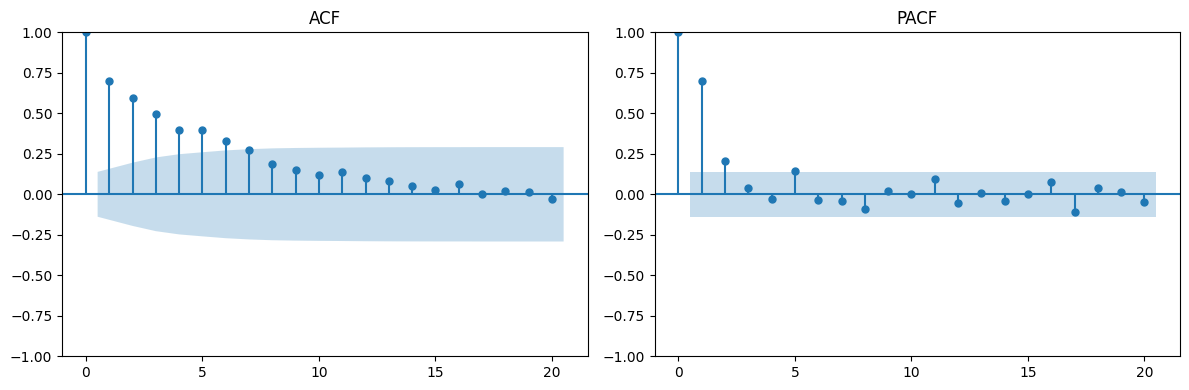

In [1]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import numpy as np

# Pipeline: Generate data -> Plot ACF & PACF -> Identify model type

np.random.seed(42)
n = 200

# AR(2) process
y_ar = np.zeros(n)
for t in range(2, n):
    y_ar[t] = 0.6*y_ar[t-1] + 0.2*y_ar[t-2] + np.random.randn()

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y_ar, lags=20, ax=axes[0], title='ACF')
plot_pacf(y_ar, lags=20, ax=axes[1], title='PACF')
plt.tight_layout()
plt.show()

# Output: ACF tails off, PACF cuts off after lag 2 → AR(2)



In [7]:

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
import numpy as np

# Pipeline: Create data -> Fit model -> Forecast

np.random.seed(42)
n = 50
data = 100 + np.cumsum(np.random.randn(n))  # trending data
print(data[-5:])  # Show last 5 values
# Simple Exponential Smoothing
ses_model = SimpleExpSmoothing(data).fit(smoothing_level=0.3)
ses_forecast = ses_model.forecast(5)

# Holt's method (with trend)
holt_model = ExponentialSmoothing(data, trend='add').fit()
holt_forecast = holt_model.forecast(5)
print("SES forecast:", ses_forecast)
print("Holt forecast:", holt_forecast)

print(f"SES forecast: {ses_forecast[0]:.2f}")
print(f"Holt forecast: {holt_forecast[0]:.2f}")

# Output: Holt's captures trend better; SES stays flat




[89.54924315 89.08860438 90.1457266  90.48934489 88.72630474]
SES forecast: [89.8753234 89.8753234 89.8753234 89.8753234 89.8753234]
Holt forecast: [88.48609191 88.24587905 88.0056662  87.76545334 87.52524049]
SES forecast: 89.88
Holt forecast: 88.49


c:\python314\Lib\site-packages\pandas\util\_decorators.py:220: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


In [9]:
data

array([102.48357077, 106.30867849, 115.89869673, 123.61514928,
       115.48948716, 113.82931522, 119.89606408, 112.83717365,
       104.99237403, 110.71280022, 109.0226575 , 114.67135123,
       125.20981136, 121.43359878, 128.03566488, 137.18856235,
       135.59609844, 140.57123666, 131.45987962, 125.93848149,
       138.66798981, 130.8711185 , 135.67738699, 133.87625907,
       145.27808638, 155.55461295, 154.90528615, 165.87849009,
       161.65706059, 161.54153125, 156.99146694, 166.26139092,
       155.27225984, 150.71144536, 163.45247052, 158.89578175,
       173.04431798, 169.20164938, 178.01932379, 188.98430618,
       192.35258694, 187.85684141, 183.42175859, 179.49448152,
       171.94713601, 176.40077896, 181.03655211, 194.28561113,
       197.71809145, 194.18479922, 210.28067388, 210.0745886 ,
       209.27564404, 214.05838144, 213.15499761, 209.6564006 ,
       199.14365835, 202.45393812, 208.99606312, 217.87772564])

In [13]:
np.arange(7)*np.pi/6

array([0.        , 0.52359878, 1.04719755, 1.57079633, 2.0943951 ,
       2.61799388, 3.14159265])

In [19]:

import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# Pipeline: Load → Split → Train → Evaluate

# Step 1-2: Sample data (monthly sales)
np.random.seed(42)
data = 100 + 2*np.arange(60) + 10*np.sin(np.arange(60)*np.pi/6) + np.random.randn(60)*5

# Step 3: Train-test split (last 12 months for test)
train, test = data[:-12], data[-12:]

# Step 4-5: Fit ARIMA
model = ARIMA(train, order=(0, 1, 0)).fit()

# Step 6: Forecast and evaluate
forecast = model.forecast(steps=12)
mae = mean_absolute_error(test, forecast)
print(f"MAE: {mae:.2f}")

# Output: MAE score to compare with baseline



MAE: 12.97


In [1]:

from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Pipeline: Create data -> Apply TimeSeriesSplit -> Train/Evaluate each fold

data = np.arange(100)  # Sample data

# TimeSeriesSplit with 5 folds
tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(tscv.split(data)):
    print(f"Fold {fold+1}:")
    print(f"  Train: {train_idx[0]}-{train_idx[-1]}")
    print(f"  Test:  {test_idx[0]}-{test_idx[-1]}")

# Output shows expanding training window, test always comes after train




Fold 1:
  Train: 0-19
  Test:  20-35
Fold 2:
  Train: 0-35
  Test:  36-51
Fold 3:
  Train: 0-51
  Test:  52-67
Fold 4:
  Train: 0-67
  Test:  68-83
Fold 5:
  Train: 0-83
  Test:  84-99


In [2]:

from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

np.random.seed(42)
data = np.cumsum(np.random.randn(100))

tscv = TimeSeriesSplit(n_splits=5)
errors = []

for train_idx, test_idx in tscv.split(data):
    train, test = data[train_idx], data[test_idx]
    model = ARIMA(train, order=(1,1,0)).fit()
    pred = model.forecast(len(test))
    errors.append(np.mean(np.abs(test - pred)))

print(f"Average MAE across folds: {np.mean(errors):.3f}")




Average MAE across folds: 1.455
